# Dataset 2 PCA Analysis 

This notebook applies Principal Component Analysis (PCA) to the second fitness dataset.

The goal is to reduce the dimensionality of the data and explore whether important patterns can be captured in fewer dimensions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
# Load dataset
df = pd.read_csv("../data/gym_dataset.csv")

print("Shape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape of dataset:
(973, 15)

Columns:
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## Selected Variables for PCA

For PCA, I selected numerical variables related to workout performance and body composition:

- Session Duration (hours)
- Avg_BPM
- Calories_Burned
- Weight (kg)
- BMI
- Fat_Percentage

These variables are suitable for PCA because they are numerical and may contain correlated information.

In [5]:
pca_features = [
    "Session_Duration (hours)",
    "Avg_BPM",
    "Calories_Burned",
    "Weight (kg)",
    "BMI",
    "Fat_Percentage"
]

X = df[pca_features].copy().dropna().reset_index(drop=True)

print("Shape of selected PCA data:")
print(X.shape)

display(X.head())

Shape of selected PCA data:
(973, 6)


,Session_Duration (hours),Avg_BPM,Calories_Burned,Weight (kg),BMI,Fat_Percentage
0,1.69,157,1313.0,88.3,30.20,12.6
1,1.30,151,883.0,74.9,32.00,33.9
2,1.11,122,677.0,68.1,24.71,33.4
3,0.59,164,532.0,53.2,18.41,28.8
4,0.64,158,556.0,46.1,14.39,29.2


## Distribution Before Scaling

Before applying PCA, I examine the distribution of the selected variables.

This helps me understand the spread and scale of the data before standardization.

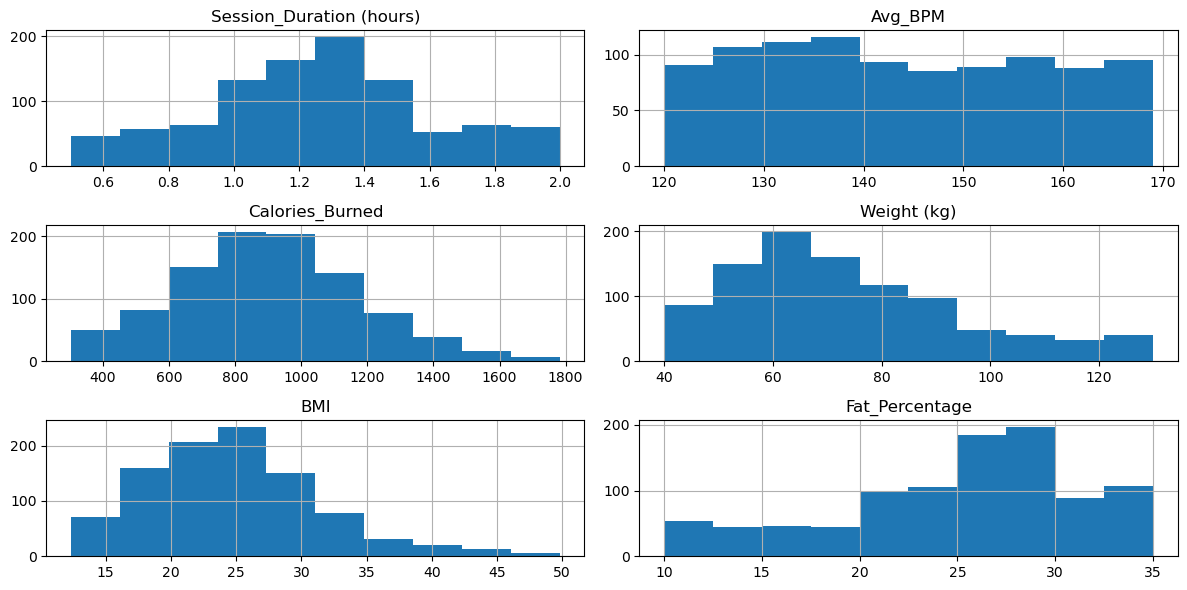

In [6]:
X.hist(figsize=(12, 6))
plt.tight_layout()
plt.show()

## Data Standardization

PCA is sensitive to scale, so the data must be standardized.

Standardization transforms the variables to have:
- mean = 0
- standard deviation = 1

This ensures that all variables contribute fairly to the PCA.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=pca_features)

display(scaled_df.head())

,Session_Duration (hours),Avg_BPM,Calories_Burned,Weight (kg),BMI,Fat_Percentage
0,1.264598,0.922970,1.495690,0.681493,0.794278,-1.978321
1,0.127098,0.504494,-0.082284,0.049316,1.064652,1.426301
2,-0.427068,-1.518142,-0.838243,-0.271491,-0.030361,1.346380
3,-1.943735,1.411193,-1.370351,-0.974433,-0.976669,0.611110
4,-1.797902,0.992716,-1.282278,-1.309393,-1.580503,0.675047


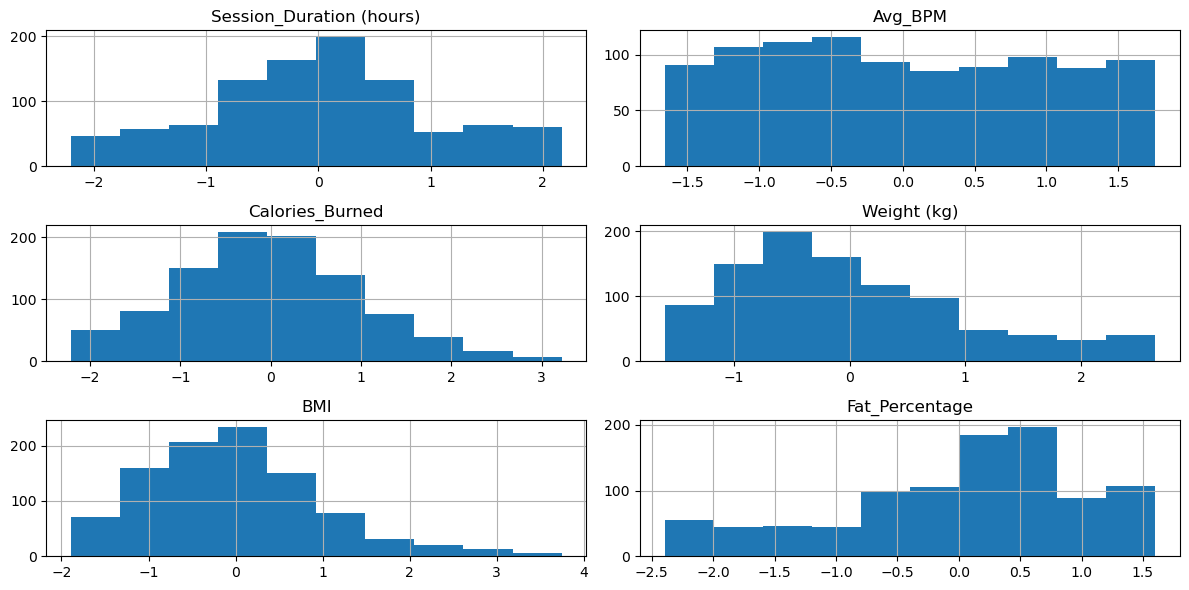

In [8]:
scaled_df.hist(figsize=(12, 6))
plt.tight_layout()
plt.show()

## Distribution After Scaling

After standardization, the variables are centered around zero and have a similar spread.

This makes the dataset suitable for PCA.

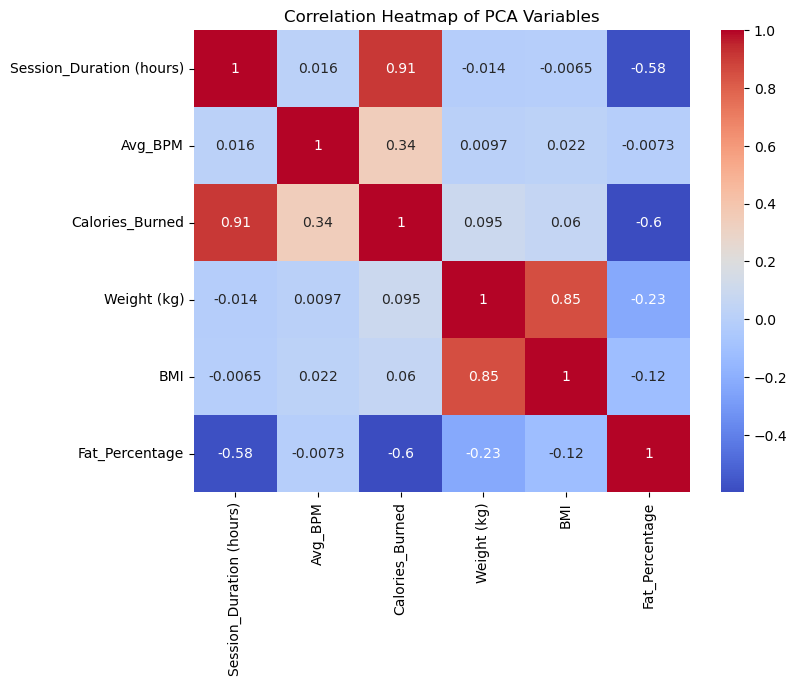

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(scaled_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of PCA Variables")
plt.show()

## Correlation Structure

The correlation heatmap helps identify how strongly the selected variables are related.

PCA works especially well when variables contain overlapping information.

## PCA Step 1: Covariance Matrix

The covariance matrix shows how the standardized variables move together.

This is an important step in PCA because the principal components are derived from the covariance structure of the data.

In [10]:
cov_matrix = np.cov(scaled_df, rowvar=False)

cov_df = pd.DataFrame(cov_matrix, index=pca_features, columns=pca_features)

display(cov_df)

,Session_Duration (hours),Avg_BPM,Calories_Burned,Weight (kg),BMI,Fat_Percentage
Session_Duration (hours),1.001029,0.016031,0.909075,-0.013680,-0.006499,-0.582118
Avg_BPM,0.016031,1.001029,0.340008,0.009727,0.021628,-0.007309
Calories_Burned,0.909075,0.340008,1.001029,0.095542,0.059822,-0.598230
Weight (kg),-0.013680,0.009727,0.095542,1.001029,0.854035,-0.225744
BMI,-0.006499,0.021628,0.059822,0.854035,1.001029,-0.119380
Fat_Percentage,-0.582118,-0.007309,-0.598230,-0.225744,-0.119380,1.001029


## PCA Step 2: Eigenvalues and Eigenvectors

Eigenvectors represent directions in the data.

Eigenvalues represent how much variance is explained by each direction.

The first principal component corresponds to the direction with the highest eigenvalue.

In [11]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[2.49590991 1.82804206 1.0463639  0.46939552 0.02708573 0.13937572]

Eigenvectors:
[[ 0.55071947  0.24512588  0.18090388 -0.43374285  0.64213232 -0.05855232]
 [ 0.14631967  0.05693069 -0.93971669  0.18308374  0.23622508 -0.05440636]
 [ 0.58866811  0.18823519 -0.13676581 -0.2706511  -0.70575434  0.16730591]
 [ 0.21491459 -0.6687469  -0.00264391  0.02922627  0.15474379  0.69410554]
 [ 0.18583541 -0.67316242 -0.03813013 -0.21160064 -0.09622787 -0.67589127]
 [-0.49804155 -0.02948981 -0.25306235 -0.8120754  -0.02385699  0.16434353]]


In [12]:
sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

print("Sorted Eigenvalues:")
print(sorted_eigenvalues)

print("\nSorted Eigenvectors:")
print(sorted_eigenvectors)

Sorted Eigenvalues:
[2.49590991 1.82804206 1.0463639  0.46939552 0.13937572 0.02708573]

Sorted Eigenvectors:
[[ 0.55071947  0.24512588  0.18090388 -0.43374285 -0.05855232  0.64213232]
 [ 0.14631967  0.05693069 -0.93971669  0.18308374 -0.05440636  0.23622508]
 [ 0.58866811  0.18823519 -0.13676581 -0.2706511   0.16730591 -0.70575434]
 [ 0.21491459 -0.6687469  -0.00264391  0.02922627  0.69410554  0.15474379]
 [ 0.18583541 -0.67316242 -0.03813013 -0.21160064 -0.67589127 -0.09622787]
 [-0.49804155 -0.02948981 -0.25306235 -0.8120754   0.16434353 -0.02385699]]


## PCA Step 3: Scree Plot

A scree plot shows the eigenvalues in descending order.

It helps determine how many principal components are worth keeping.

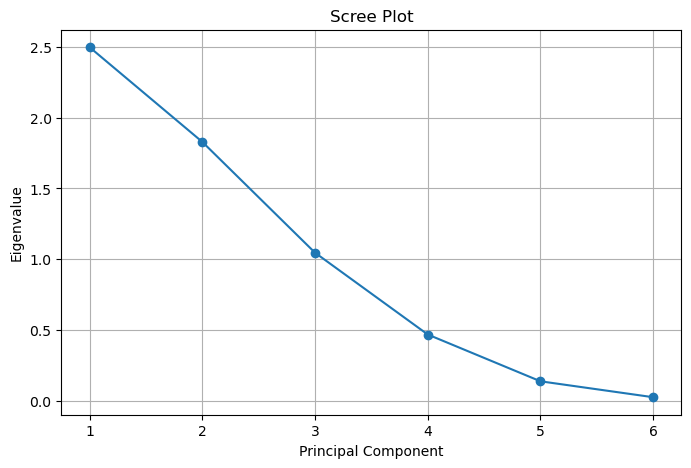

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(sorted_eigenvalues) + 1),
    sorted_eigenvalues,
    marker="o"
)
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.xticks(range(1, len(sorted_eigenvalues) + 1))
plt.grid(True)
plt.show()

## PCA Step 4: Manual Projection onto Principal Components

After computing the eigenvectors, I project the standardized data onto the new PCA axes.

This creates a lower-dimensional representation of the original data.

In [14]:
W = sorted_eigenvectors[:, :2]

X_pca_manual = np.dot(scaled_df.values, W)

pca_manual_df = pd.DataFrame(X_pca_manual, columns=["PC1", "PC2"])

display(pca_manual_df.head())

,PC1,PC2
0,2.991306,-0.288011
1,-0.406533,-0.747337
2,-1.685319,-0.186609
3,-2.365927,0.637017
4,-2.511044,1.294115


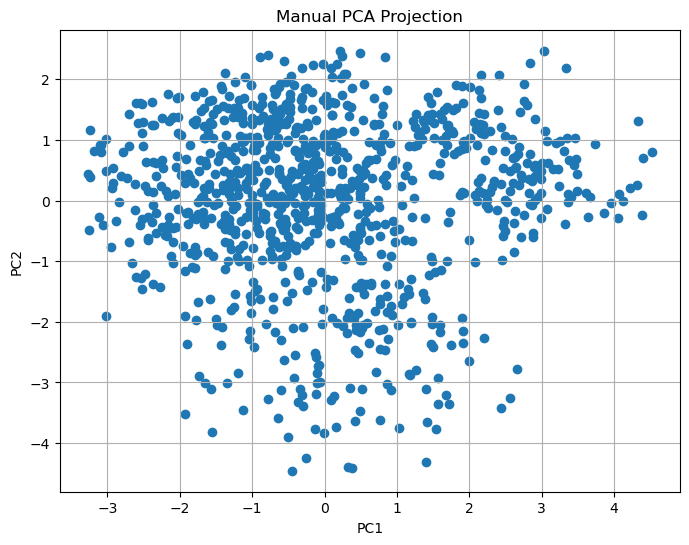

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_manual_df["PC1"], pca_manual_df["PC2"])
plt.title("Manual PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

## PCA Step 5: PCA with Scikit-learn

To validate the manual PCA process, I also apply PCA using scikit-learn.

This is the practical implementation commonly used in data science workflows.

In [16]:
pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(X_pca_sklearn, columns=["PC1", "PC2"])

display(pca_df.head())

,PC1,PC2
0,2.991306,0.288011
1,-0.406533,0.747337
2,-1.685319,0.186609
3,-2.365927,-0.637017
4,-2.511044,-1.294115


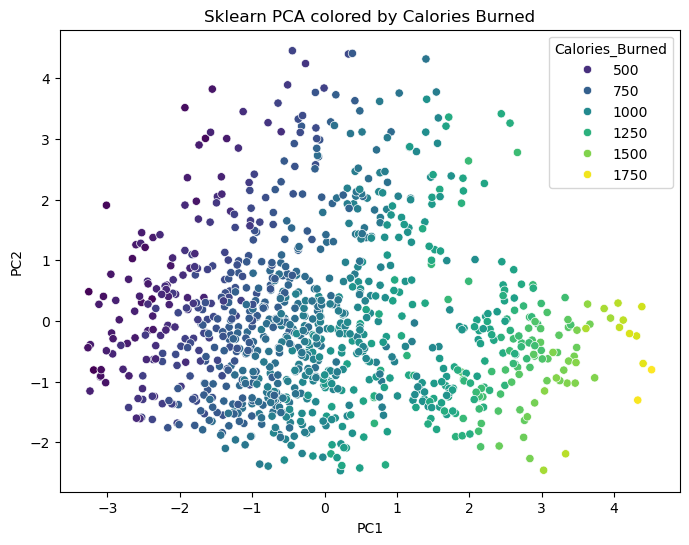

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=X["Calories_Burned"],
    palette="viridis"
)
plt.title("Sklearn PCA colored by Calories Burned")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Explained Variance

Explained variance shows how much information is captured by each principal component.

This helps evaluate how effective the dimensionality reduction is.

In [18]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance by 2 components:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.41555746 0.30436055]

Total explained variance by 2 components:
0.7199180052704321


## Interpretation

The PCA result shows how the fitness data can be represented in fewer dimensions.

If the points form visible structure or gradients, it suggests that the selected variables contain meaningful patterns.

Coloring by calories burned helps reveal whether workout output is related to the PCA structure.

## Comparison: Manual PCA vs Sklearn PCA

In this notebook, PCA was implemented both manually and with scikit-learn.

The manual version shows the mathematical process behind PCA:
- covariance matrix
- eigenvalues
- eigenvectors
- projection

The scikit-learn version provides a practical and efficient implementation.

Both approaches should reveal a similar overall structure.

## Limitations of PCA

Although PCA is useful, it has some limitations:

- Information loss may occur when dimensions are reduced
- PCA only captures linear relationships
- Results are sensitive to scaling
- Principal components can be difficult to interpret directly

Despite these limitations, PCA is a valuable tool for finding structure in numerical data.

In [19]:
import plotly.express as px

In [20]:
pca = PCA(n_components=3)

In [21]:
X_pca = pca.fit_transform(scaled_df)

variance_ratio = pca.explained_variance_ratio_

In [22]:
df_3d = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'Calories': X['Calories_Burned']
})

In [23]:
import plotly.express as px

fig = px.scatter_3d(
    df_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Calories',
    color_continuous_scale='viridis',
    opacity=0.7,
    title=f'3D PCA (Total variance: {variance_ratio[:3].sum():.2%})'
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({variance_ratio[0]:.2%})',
        yaxis_title=f'PC2 ({variance_ratio[1]:.2%})',
        zaxis_title=f'PC3 ({variance_ratio[2]:.2%})'
    )
)

fig.show()

In [26]:
fig.show(renderer="browser")